In [1]:
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import time
import torchvision.models as models
from matplotlib import pyplot as plt

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## Load Data

In [3]:
image_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2,contrast=0.2),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])   
])

In [4]:
dataset_path = "./dataset"
dataset = datasets.ImageFolder(root=dataset_path,transform=image_transforms)

In [5]:
len(dataset)

2300

In [6]:
dataset.classes

['F_Breakage', 'F_Crushed', 'F_Normal', 'R_Breakage', 'R_Crushed', 'R_Normal']

In [7]:
num_classes = len(dataset.classes)
num_classes

6

In [8]:
train_size = int(0.75 * len(dataset))
val_size = len(dataset)-train_size
train_size,val_size


(1725, 575)

In [9]:
from torch.utils.data import random_split
train_dataset, val_dataset = random_split(dataset,[train_size,val_size])

In [10]:
train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)
val_loader = DataLoader(val_dataset,batch_size=32,shuffle=True)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0836544..1.7685405].


torch.Size([32, 3, 224, 224])
torch.Size([32])


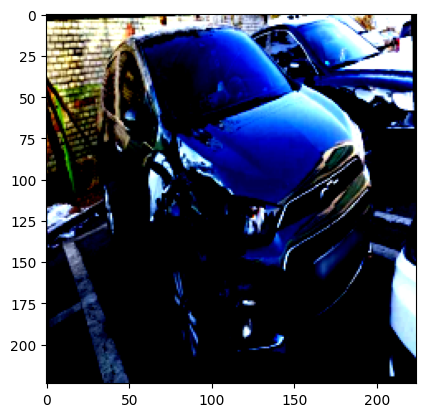

In [12]:
for images, labels in train_loader:
    print(images.shape)
    print(labels.shape)
    break

labels[0]

images[0].shape

images[0].permute(1,2,0).shape

plt.imshow(images[0].permute(1,2,0))
plt.show()

## Model 1 : CNN

In [13]:
class CarClassifierCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1), # (16, 224, 224)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0), # (16, 112, 112),
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0), # (32, 56, 56)
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0), # (64, 28, 28),
            nn.Flatten(),
            nn.Linear(64*28*28, 512),
            nn.ReLU(),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.network(x)
        return x

In [34]:
# Instantiate the model, loss function, and optimizer
model = CarClassifierCNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [13]:
def train_model(model, criterion, optimizer, epochs=5):
    start = time.time()

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for batch_num, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)

            # Zero the parameter gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward pass and optimization
            loss.backward()
            optimizer.step()

            if (batch_num+1) % 10 == 0:
                print(f"Batch: {batch_num+1}, Epoch: {epoch+1}, Loss: {loss.item():.2f}")

            running_loss += loss.item() * images.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)
        print(f"Epoch [{epoch+1}/{epochs}], Avg Loss: {epoch_loss:.4f}")

        # Validation
        model.eval()
        correct = 0
        total = 0
        all_labels = []
        all_predictions = []

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data,1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                all_labels.extend(labels.cpu().numpy())
                all_predictions.extend(predicted.cpu().numpy())

        print(f"*** Validation Accuracy: {100 * correct / total:.2f}% ***")

    end = time.time()
    print(f"Execution time: {end - start} seconds")

    return all_labels, all_predictions

In [38]:
all_labels, all_predictions = train_model(model, criterion, optimizer, epochs=10)

Batch: 10, Epoch: 1, Loss: 0.75
Batch: 20, Epoch: 1, Loss: 0.69
Batch: 30, Epoch: 1, Loss: 1.04
Batch: 40, Epoch: 1, Loss: 0.92
Batch: 50, Epoch: 1, Loss: 0.80
Epoch [1/10], Avg Loss: 0.8204
*** Validation Accuracy: 55.65% ***
Batch: 10, Epoch: 2, Loss: 0.62
Batch: 20, Epoch: 2, Loss: 0.53
Batch: 30, Epoch: 2, Loss: 0.88
Batch: 40, Epoch: 2, Loss: 0.60
Batch: 50, Epoch: 2, Loss: 0.82
Epoch [2/10], Avg Loss: 0.7533
*** Validation Accuracy: 57.04% ***
Batch: 10, Epoch: 3, Loss: 0.71
Batch: 20, Epoch: 3, Loss: 0.56
Batch: 30, Epoch: 3, Loss: 0.73
Batch: 40, Epoch: 3, Loss: 0.54
Batch: 50, Epoch: 3, Loss: 0.72
Epoch [3/10], Avg Loss: 0.7386
*** Validation Accuracy: 59.13% ***
Batch: 10, Epoch: 4, Loss: 0.62
Batch: 20, Epoch: 4, Loss: 0.71
Batch: 30, Epoch: 4, Loss: 0.80
Batch: 40, Epoch: 4, Loss: 0.87
Batch: 50, Epoch: 4, Loss: 0.50
Epoch [4/10], Avg Loss: 0.6938
*** Validation Accuracy: 57.57% ***
Batch: 10, Epoch: 5, Loss: 0.75
Batch: 20, Epoch: 5, Loss: 0.58
Batch: 30, Epoch: 5, Loss: 0

## Model 2 : Transfer Learning with EfficientNet

In [14]:
model = models.efficientnet_b0(weights='DEFAULT')
model.classifier[1].in_features

1280

In [15]:
class CarClassifierEfficientNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.model = models.efficientnet_b0(weights='DEFAULT')

        for param in self.model.parameters():
            param.requires_grad = False

        in_features = self.model.classifier[1].in_features

        self.model.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        x = self.model(x)
        return x

In [17]:
model = CarClassifierEfficientNet(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

train_model(model, criterion, optimizer, epochs=10)

Batch: 10, Epoch: 1, Loss: 1.73
Batch: 20, Epoch: 1, Loss: 1.48
Batch: 30, Epoch: 1, Loss: 1.49
Batch: 40, Epoch: 1, Loss: 1.36
Batch: 50, Epoch: 1, Loss: 1.30
Epoch [1/10], Avg Loss: 1.4731
*** Validation Accuracy: 59.13% ***
Batch: 10, Epoch: 2, Loss: 1.20
Batch: 20, Epoch: 2, Loss: 1.18
Batch: 30, Epoch: 2, Loss: 1.05
Batch: 40, Epoch: 2, Loss: 1.07
Batch: 50, Epoch: 2, Loss: 1.02
Epoch [2/10], Avg Loss: 1.1173
*** Validation Accuracy: 62.09% ***
Batch: 10, Epoch: 3, Loss: 0.81
Batch: 20, Epoch: 3, Loss: 1.01
Batch: 30, Epoch: 3, Loss: 1.13
Batch: 40, Epoch: 3, Loss: 0.93
Batch: 50, Epoch: 3, Loss: 0.87
Epoch [3/10], Avg Loss: 1.0040
*** Validation Accuracy: 64.35% ***
Batch: 10, Epoch: 4, Loss: 1.03
Batch: 20, Epoch: 4, Loss: 0.78
Batch: 30, Epoch: 4, Loss: 0.96
Batch: 40, Epoch: 4, Loss: 0.81
Batch: 50, Epoch: 4, Loss: 0.92
Epoch [4/10], Avg Loss: 0.9548
*** Validation Accuracy: 64.70% ***
Batch: 10, Epoch: 5, Loss: 1.05
Batch: 20, Epoch: 5, Loss: 0.92
Batch: 30, Epoch: 5, Loss: 0

([np.int64(5),
  np.int64(2),
  np.int64(5),
  np.int64(4),
  np.int64(3),
  np.int64(0),
  np.int64(1),
  np.int64(1),
  np.int64(5),
  np.int64(4),
  np.int64(5),
  np.int64(4),
  np.int64(2),
  np.int64(0),
  np.int64(5),
  np.int64(0),
  np.int64(0),
  np.int64(3),
  np.int64(1),
  np.int64(1),
  np.int64(3),
  np.int64(5),
  np.int64(2),
  np.int64(0),
  np.int64(3),
  np.int64(4),
  np.int64(5),
  np.int64(2),
  np.int64(0),
  np.int64(2),
  np.int64(1),
  np.int64(3),
  np.int64(0),
  np.int64(2),
  np.int64(3),
  np.int64(4),
  np.int64(2),
  np.int64(5),
  np.int64(0),
  np.int64(0),
  np.int64(3),
  np.int64(4),
  np.int64(5),
  np.int64(1),
  np.int64(3),
  np.int64(5),
  np.int64(2),
  np.int64(3),
  np.int64(0),
  np.int64(2),
  np.int64(4),
  np.int64(1),
  np.int64(2),
  np.int64(2),
  np.int64(0),
  np.int64(5),
  np.int64(0),
  np.int64(3),
  np.int64(2),
  np.int64(0),
  np.int64(3),
  np.int64(0),
  np.int64(4),
  np.int64(2),
  np.int64(2),
  np.int64(0),
  np.int64

## Model 2 : Transfer Learning with ResNet

In [16]:
# Load the pre-trained ResNet model
class CarClassifierResNet(nn.Module):
    def __init__(self, num_classes,dropout_rate=0.5):
        super().__init__()
        self.model = models.resnet50(weights='DEFAULT')
        # Freeze all layers except the final fully connected layer
        for param in self.model.parameters():
            param.requires_grad = False

        # Unfreeze layer4 and fc layers
        for param in self.model.layer4.parameters():
            param.requires_grad = True

        # Replace the final fully connected layer
        self.model.fc = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(self.model.fc.in_features, num_classes)
        )

    def forward(self, x):
        x = self.model(x)
        return x

In [19]:
model = CarClassifierResNet(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

labels, predictions =  train_model(model, criterion, optimizer, epochs=10)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\Asus/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


100%|█████████████████████████████████████████████████████████████████████████████| 97.8M/97.8M [00:06<00:00, 16.2MB/s]


Batch: 10, Epoch: 1, Loss: 1.06
Batch: 20, Epoch: 1, Loss: 0.76
Batch: 30, Epoch: 1, Loss: 1.16
Batch: 40, Epoch: 1, Loss: 1.05
Batch: 50, Epoch: 1, Loss: 0.69
Epoch [1/10], Avg Loss: 0.8679
*** Validation Accuracy: 64.87% ***
Batch: 10, Epoch: 2, Loss: 0.57
Batch: 20, Epoch: 2, Loss: 0.42
Batch: 30, Epoch: 2, Loss: 0.53
Batch: 40, Epoch: 2, Loss: 0.47
Batch: 50, Epoch: 2, Loss: 0.33
Epoch [2/10], Avg Loss: 0.5038
*** Validation Accuracy: 78.61% ***
Batch: 10, Epoch: 3, Loss: 0.15
Batch: 20, Epoch: 3, Loss: 0.22
Batch: 30, Epoch: 3, Loss: 0.50
Batch: 40, Epoch: 3, Loss: 0.19
Batch: 50, Epoch: 3, Loss: 0.56
Epoch [3/10], Avg Loss: 0.3475
*** Validation Accuracy: 80.70% ***
Batch: 10, Epoch: 4, Loss: 0.23
Batch: 20, Epoch: 4, Loss: 0.18
Batch: 30, Epoch: 4, Loss: 0.17
Batch: 40, Epoch: 4, Loss: 0.21
Batch: 50, Epoch: 4, Loss: 0.20
Epoch [4/10], Avg Loss: 0.2376
*** Validation Accuracy: 78.43% ***
Batch: 10, Epoch: 5, Loss: 0.14
Batch: 20, Epoch: 5, Loss: 0.16
Batch: 30, Epoch: 5, Loss: 0

In [ ]:
## 🔥 Hyperparameter Optimization Result (Optuna)

After performing hyperparameter tuning using Optuna, the model achieved its best performance with the following values:

- **Learning Rate (lr):** 0.0005621205198689565  
- **Dropout Rate:** 0.41674820426452264  


In [17]:
model = CarClassifierResNet(num_classes=num_classes,dropout_rate=0.4).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.0005)

labels, predictions =  train_model(model, criterion, optimizer, epochs=10)

Batch: 10, Epoch: 1, Loss: 1.22
Batch: 20, Epoch: 1, Loss: 0.73
Batch: 30, Epoch: 1, Loss: 0.55
Batch: 40, Epoch: 1, Loss: 0.50
Batch: 50, Epoch: 1, Loss: 0.57
Epoch [1/10], Avg Loss: 0.9387
*** Validation Accuracy: 75.83% ***
Batch: 10, Epoch: 2, Loss: 0.47
Batch: 20, Epoch: 2, Loss: 0.81
Batch: 30, Epoch: 2, Loss: 0.28
Batch: 40, Epoch: 2, Loss: 0.58
Batch: 50, Epoch: 2, Loss: 0.28
Epoch [2/10], Avg Loss: 0.4405
*** Validation Accuracy: 74.43% ***
Batch: 10, Epoch: 3, Loss: 0.20
Batch: 20, Epoch: 3, Loss: 0.20
Batch: 30, Epoch: 3, Loss: 0.30
Batch: 40, Epoch: 3, Loss: 0.44
Batch: 50, Epoch: 3, Loss: 0.24
Epoch [3/10], Avg Loss: 0.3092
*** Validation Accuracy: 76.17% ***
Batch: 10, Epoch: 4, Loss: 0.38
Batch: 20, Epoch: 4, Loss: 0.05
Batch: 30, Epoch: 4, Loss: 0.12
Batch: 40, Epoch: 4, Loss: 0.16
Batch: 50, Epoch: 4, Loss: 0.45
Epoch [4/10], Avg Loss: 0.2053
*** Validation Accuracy: 78.43% ***
Batch: 10, Epoch: 5, Loss: 0.09
Batch: 20, Epoch: 5, Loss: 0.21
Batch: 30, Epoch: 5, Loss: 0

In [18]:
class_names = dataset.classes

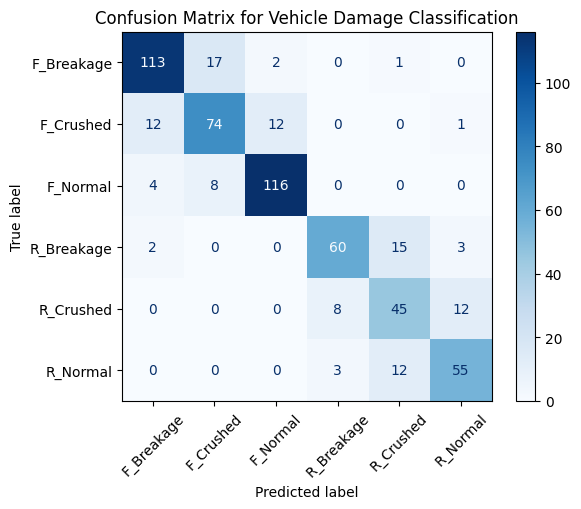

In [19]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from matplotlib import pyplot as plt

conf_matrix = confusion_matrix(labels, predictions, labels=np.arange(num_classes))
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix for Vehicle Damage Classification")
plt.show()

In [20]:
torch.save(model.state_dict(),"saved_model.pth")